In [5]:
#step1: imports and load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")
print(f"pandas version: {pd.__version__}")

import pandas as pd

rna_url = "https://osdr.nasa.gov/geode-py/ws/studies/OSD-569/download?source=datamanager&file=GLDS-561_long-readRNAseq_Direct_RNA_seq_Gene_Expression_Processed.xlsx"

# Load the FP1 sheet specifically
# skiprows handles the metadata rows at the top
rna = pd.read_excel(
    rna_url,
    sheet_name='I4-FP1',
    skiprows=[0, 1, 2, 3, 4, 5, 6, 9],
    header=[0, 1],
    index_col=0
)

# Flatten the multi-level columns
rna.columns = [f"{str(a)}_{str(b)}".strip("_") for a, b in rna.columns]

print(rna.shape)
print(rna.columns.tolist())
rna.head()

All imports successful
pandas version: 3.0.2
(61852, 38)
['C001_L-92', 'C001_L-44', 'C001_L-3', 'C001_R+1', 'C002_L-92', 'C002_L-44', 'C002_L-3', 'C002_R+1', 'C003_L-92', 'C003_L-44', 'C003_L-3', 'C003_R+1', 'C004_L-92', 'C004_L-44', 'C004_L-3', 'C004_R+1', 'C001_L-92.1', 'C001_L-44.1', 'C001_L-3.1', 'C001_R+1.1', 'C002_L-92.1', 'C002_L-44.1', 'C002_L-3.1', 'C002_R+1.1', 'C003_L-92.1', 'C003_L-44.1', 'C003_L-3.1', 'C003_R+1.1', 'C004_L-92.1', 'C004_L-44.1', 'C004_L-3.1', 'C004_R+1.1', 'DESeq2_log2FC', 'DESeq2_p-value', 'DESeq2_adjusted p-value', 'pipeline-transcriptome-de_log2FC', 'pipeline-transcriptome-de_p-value', 'pipeline-transcriptome-de_adjusted p-value']


,C001_L-92,C001_L-44,C001_L-3,C001_R+1,C002_L-92,C002_L-44,C002_L-3,C002_R+1,C003_L-92,C003_L-44,...,C004_L-92.1,C004_L-44.1,C004_L-3.1,C004_R+1.1,DESeq2_log2FC,DESeq2_p-value,DESeq2_adjusted p-value,pipeline-transcriptome-de_log2FC,pipeline-transcriptome-de_p-value,pipeline-transcriptome-de_adjusted p-value
ENSG00000000003.15,1,0,0,0,0,0,1,0,0,1,...,0,0,0,1,0.0,0.921127,NaN,-0.210232,0.891218,0.988984
ENSG00000000005.6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN
ENSG00000000419.14,5,9,8,7,2,3,36,2,8,5,...,3,9,11,30,0.0,0.869039,NaN,0.047740,0.899645,0.989714
ENSG00000000457.14,2,0,2,0,2,1,7,2,0,1,...,2,1,3,14,0.0,0.401304,NaN,0.555946,0.356440,0.932855
ENSG00000000460.17,0,0,0,0,0,0,1,0,1,1,...,2,0,0,4,0.0,0.793469,NaN,-0.624943,0.532931,0.932855


In [6]:
# step 2: filter to significant DEGs


# Identify the right column names from Step 1 output
logfc_col = 'pipeline-transcriptome-de_log2FC'  # adjust as needed
padj_col = 'pipeline-transcriptome-de_adjusted p-value'  # adjust as needed

# Convert to numeric (NAs become NaN)
rna[logfc_col] = pd.to_numeric(rna[logfc_col], errors='coerce')
rna[padj_col] = pd.to_numeric(rna[padj_col], errors='coerce')

# Filter
degs = rna[
    (rna[padj_col] < 0.05) & 
    (abs(rna[logfc_col]) > 1)
].copy()

print(f"Total genes: {len(rna)}")
print(f"Significant DEGs: {len(degs)}")
print(f"\nUpregulated: {(degs[logfc_col] > 1).sum()}")
print(f"Downregulated: {(degs[logfc_col] < -1).sum()}")

degs[[logfc_col, padj_col]].head(20)
# use.head(20) for top 20 later

clean_ids = degs.index.str.split('.').str[0].tolist()
print('\n'.join(clean_ids))

Total genes: 61852
Significant DEGs: 61

Upregulated: 5
Downregulated: 56
ENSG00000004939
ENSG00000008441
ENSG00000029534
ENSG00000057757
ENSG00000063854
ENSG00000066926
ENSG00000070182
ENSG00000079308
ENSG00000086506
ENSG00000090013
ENSG00000099804
ENSG00000100325
ENSG00000103342
ENSG00000104522
ENSG00000105647
ENSG00000106992
ENSG00000107262
ENSG00000123240
ENSG00000130821
ENSG00000133606
ENSG00000137198
ENSG00000143416
ENSG00000145335
ENSG00000158578
ENSG00000158856
ENSG00000162366
ENSG00000162722
ENSG00000164849
ENSG00000166947
ENSG00000167671
ENSG00000167705
ENSG00000167768
ENSG00000167992
ENSG00000168785
ENSG00000169877
ENSG00000170271
ENSG00000171552
ENSG00000175745
ENSG00000181788
ENSG00000183508
ENSG00000184481
ENSG00000184792
ENSG00000198876
ENSG00000206177
ENSG00000211964
ENSG00000212907
ENSG00000213648
ENSG00000218175
ENSG00000220842
ENSG00000223609
ENSG00000225972
ENSG00000235169
ENSG00000243716
ENSG00000269242
ENSG00000275527
ENSG00000279117
ENSG00000286456
ENSG0000028868

In [7]:
# step 3: convert ENSEMBL IDs to gene symbols

# Strip version numbers (the .15, .6, etc. after the ID)
degs['ENSEMBL_clean'] = degs.index.str.split('.').str[0]

# Use mygene library for ID conversion
import mygene
mg = mygene.MyGeneInfo()

# Query
gene_info = mg.querymany(
    degs['ENSEMBL_clean'].tolist(),
    scopes='ensembl.gene',
    fields='symbol',
    species='human',
    as_dataframe=True
)

# Merge symbols back
degs = degs.merge(
    gene_info[['symbol']], 
    left_on='ENSEMBL_clean', 
    right_index=True, 
    how='left'
)

print(degs[['symbol', logfc_col, padj_col]].head(20))

                    symbol  pipeline-transcriptome-de_log2FC  \
ENSG00000004939.16  SLC4A1                         -1.621353   
ENSG00000008441.19    NFIX                         -1.265340   
ENSG00000029534.21    ANK1                         -1.761540   
ENSG00000057757.10  PITHD1                         -1.351709   
ENSG00000063854.13    HAGH                         -1.236741   
ENSG00000066926.13    FECH                         -1.440360   
ENSG00000070182.21    SPTB                         -2.341522   
ENSG00000079308.20    TNS1                         -1.360762   
ENSG00000086506.3     HBQ1                         -1.317401   
ENSG00000090013.11   BLVRB                         -1.172239   
ENSG00000099804.9    CDC34                         -1.258086   
ENSG00000100325.15   ASCC2                         -1.340248   
ENSG00000103342.13   GSPT1                         -1.123696   
ENSG00000104522.16    GFUS                         -1.394930   
ENSG00000105647.19  PIK3R2              

In [8]:
# side-track: g:profiler ORA 


# get background for g:profiler. only the genes that have a p value (non-NA) treated as background...
background = rna[rna[padj_col].notna()].index.str.split('.').str[0].tolist()
print(f"Background size: {len(background)}")
# print('\n'.join(background))    used for g:profiler input, not needed here

Background size: 19361


In [9]:
# pip install gprofiler-official
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Strip versions if not already
clean_ids = degs.index.str.split('.').str[0].tolist()
background = rna[rna[padj_col].notna()].index.str.split('.').str[0].tolist()

results = gp.profile(
    organism='hsapiens',
    query=clean_ids,
    background=background,
    sources=['GO:MF', 'GO:BP', 'GO:CC', 'KEGG', 'REAC', 'WP'],
    user_threshold=0.05
)

print(results.head())

  source             native                          name   p_value  \
0  GO:CC         GO:0005833            hemoglobin complex  0.003303   
1   KEGG         KEGG:00860          Porphyrin metabolism  0.005419   
2  GO:BP         GO:0048821       erythrocyte development  0.007469   
3  GO:BP         GO:0020027  hemoglobin metabolic process  0.008347   
4   REAC  REAC:R-HSA-189445      Metabolism of porphyrins  0.008446   

   significant                                        description  term_size  \
0         True  "An iron-containing, oxygen carrying complex. ...         13   
1         True                               Porphyrin metabolism         26   
2         True  "The process whose specific outcome is the pro...         39   
3         True  "The chemical reactions and pathways involving...         16   
4         True                           Metabolism of porphyrins         18   

   query_size  intersection_size  effective_domain_size  precision    recall  \
0          6

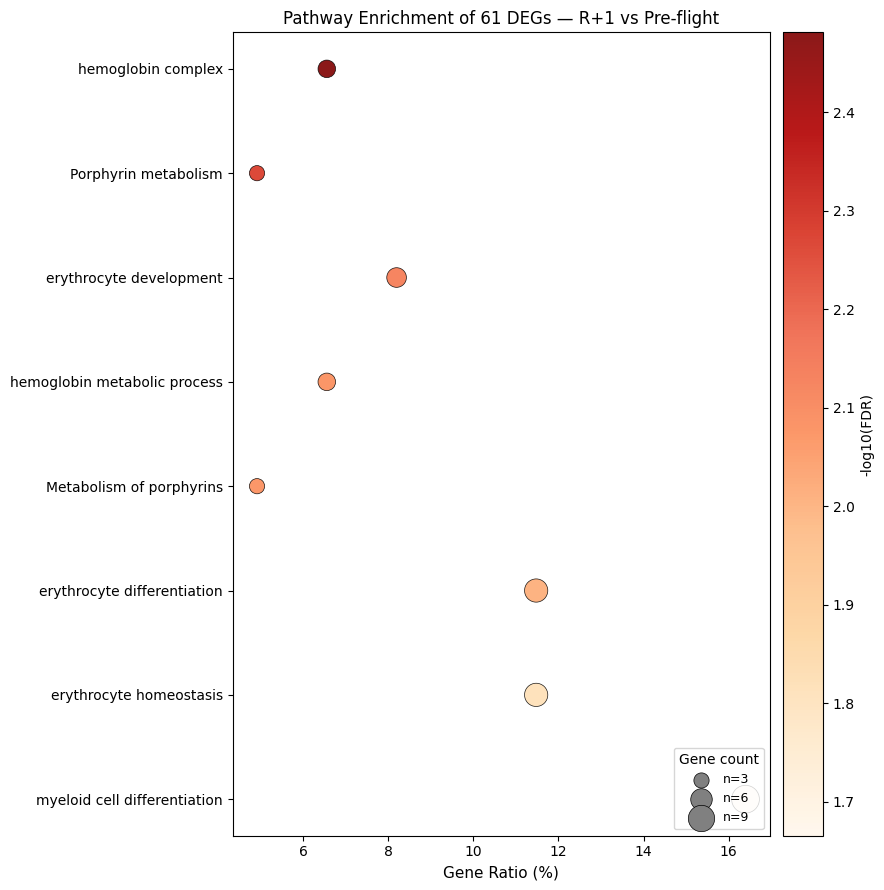

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Take top 20 most significant
top_terms = results.sort_values('p_value').head(20).copy()

# Calculate gene ratio
top_terms['gene_ratio'] = (top_terms['intersection_size'] / top_terms['query_size']) * 100
top_terms['neg_log_p'] = -np.log10(top_terms['p_value'])

# Sort so smallest p is at top of plot
top_terms = top_terms.sort_values('neg_log_p', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(9, 9))

scatter = ax.scatter(
    top_terms['gene_ratio'],
    top_terms['name'],
    s=top_terms['intersection_size'] * 40,
    c=top_terms['neg_log_p'],
    cmap='OrRd',  # cool color theme
    edgecolors='black',
    linewidths=0.5,
    alpha=0.9
)

# Color bar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('-log10(FDR)', fontsize=10)

# Size legend
sizes = [3, 6, 9]
for size in sizes:
    ax.scatter([], [], s=size*40, c='gray', edgecolors='black',
               linewidths=0.5, label=f'n={size}')
ax.legend(title='Gene count', loc='lower right', frameon=True, fontsize=9)

ax.set_xlabel('Gene Ratio (%)', fontsize=11)
ax.set_title('Pathway Enrichment of 61 DEGs — R+1 vs Pre-flight', fontsize=12)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('Plots/pathway_dotplot_full.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print(f"Total significant pathways: {len(results)}")
print(f"By source:")
print(results['source'].value_counts())

Total significant pathways: 8
By source:
source
GO:BP    5
GO:CC    1
KEGG     1
REAC     1
Name: count, dtype: int64


In [12]:
import mygene
mg = mygene.MyGeneInfo()

degs['ENSEMBL_clean'] = degs.index.str.split('.').str[0]

# Query with name field for descriptions
gene_info = mg.querymany(
    degs['ENSEMBL_clean'].tolist(),
    scopes='ensembl.gene',
    fields='symbol,name',
    species='human',
    as_dataframe=True
)

gene_info = gene_info[~gene_info.index.duplicated(keep='first')]

# Drop old symbol column if it exists, then merge
degs = degs.drop(columns=['symbol', 'name', 'domain'], errors='ignore').merge(
    gene_info[['symbol', 'name']],
    left_on='ENSEMBL_clean',
    right_index=True,
    how='left'
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 100)
print(degs[['symbol', 'name', logfc_col]].sort_values(logfc_col).to_string())

                      symbol                                                       name  pipeline-transcriptome-de_log2FC
ENSG00000279117.1        NaN                                                        NaN                         -6.036207
ENSG00000288681.1        NaN                                                        NaN                         -5.547810
ENSG00000105647.19    PIK3R2             phosphoinositide-3-kinase regulatory subunit 2                         -5.285428
ENSG00000220842.6   RPL21P16                        ribosomal protein L21 pseudogene 16                         -5.271457
ENSG00000286456.3        NaN                                                        NaN                         -5.123835
ENSG00000213648.11   SULT1A4                        sulfotransferase family 1A member 4                         -4.650328
ENSG00000289316.1        NaN                                                        NaN                         -4.520160
ENSG00000289273.1       

In [13]:
# map genes to "domains" manually for visualization, discussed additionally in write up. 

domain_map = {
    'Erythroid_RBC': [
        'HBD', 'HBM', 'HBQ1', 'AHSP',
        'ALAS2', 'FECH', 'BLVRB',
        'SPTB', 'ANK1', 'EPB42', 'DMTN',
        'SLC4A1', 'SMIM1', 'TRIM58',
    ],
    'Adaptive_Immunity': ['IGHV3-48'],
    'Protein_Degradation': ['SIAH2', 'CDC34', 'MKRN1', 'UBXN6', 'DCAF12'],
    'Transcriptional_Regulation': ['FOXO4', 'NFIX', 'NR2F1'],
    'Mitochondrial': ['MT-ND4L'],
}

gene_to_domain = {gene: dom for dom, genes in domain_map.items() for gene in genes}
degs['domain'] = degs['symbol'].map(gene_to_domain).fillna('Other')

print(degs.groupby('domain').size())

domain
Adaptive_Immunity              1
Erythroid_RBC                 14
Mitochondrial                  1
Other                         37
Protein_Degradation            5
Transcriptional_Regulation     3
dtype: int64


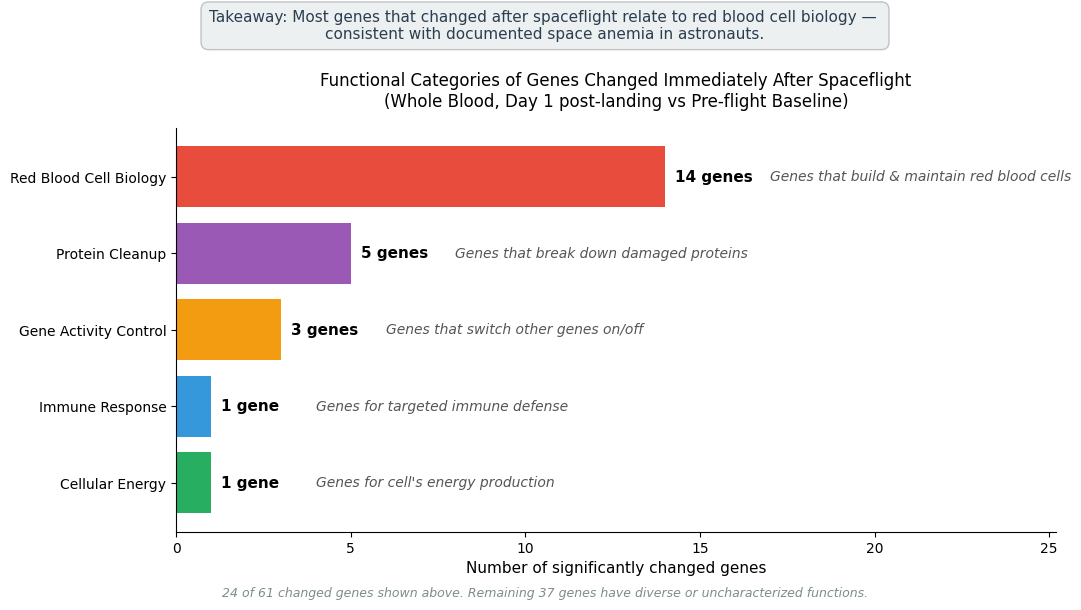

In [14]:
import matplotlib.pyplot as plt

# Get domain counts (conservative), exclude "Other" for headline figure
domain_counts = degs['domain'].value_counts()
domain_counts = domain_counts.drop('Other', errors='ignore')

# Sort by count descending
domain_counts = domain_counts.sort_values(ascending=False)

# Color palette
colors = {
    'Erythroid_RBC': '#e74c3c',
    'Protein_Degradation': '#9b59b6',
    'Transcriptional_Regulation': '#f39c12',
    'Mitochondrial': '#27ae60',
    'Adaptive_Immunity': '#3498db',
}
bar_colors = [colors.get(d, '#95a5a6') for d in domain_counts.index]

# Plain English labels with explanations
display_labels = {
    'Erythroid_RBC': 'Red Blood Cell Biology',
    'Protein_Degradation': 'Protein Cleanup',
    'Transcriptional_Regulation': 'Gene Activity Control',
    'Mitochondrial': 'Cellular Energy',
    'Adaptive_Immunity': 'Immune Response',
}

explanations = {
    'Erythroid_RBC': 'Genes that build & maintain red blood cells',
    'Protein_Degradation': 'Genes that break down damaged proteins',
    'Transcriptional_Regulation': 'Genes that switch other genes on/off',
    'Mitochondrial': "Genes for cell's energy production",
    'Adaptive_Immunity': 'Genes for targeted immune defense',
}

labels = [display_labels.get(d, d) for d in domain_counts.index]

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels, domain_counts.values, color=bar_colors)

# Count labels and explanations
# Replace this section
for bar, count, domain in zip(bars, domain_counts.values, domain_counts.index):
    gene_word = 'gene' if count == 1 else 'genes'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{count} {gene_word}',
            va='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            explanations[domain],
            va='center', fontsize=10, color='#555555', style='italic')

# Takeaway as figure-level annotation at top
fig.text(0.5, 0.95,
         'Takeaway: Most genes that changed after spaceflight relate to red blood cell biology — \nconsistent with documented space anemia in astronauts.',
         ha='center', fontsize=11, color='#2c3e50',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', edgecolor='#bdc3c7'))

ax.set_xlabel('Number of significantly changed genes', fontsize=11)
ax.set_title('Functional Categories of Genes Changed Immediately After Spaceflight\n(Whole Blood, Day 1 post-landing vs Pre-flight Baseline)', 
             fontsize=12, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(domain_counts.values) * 1.8)
ax.invert_yaxis()

# Add note about Other
fig.text(0.5, 0.02,
         '24 of 61 changed genes shown above. Remaining 37 genes have diverse or uncharacterized functions.',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

import os
os.makedirs('Plots', exist_ok=True)
plt.savefig('Plots/domain_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
degs.to_csv('degs_FP1.csv')